# 🔍 WAAM Autoencoder 이상 탐지 — Split 데이터 기반 (몰리브덴 + 인코넬 통합)

## 데이터 구조
```
D:\code\Artificial intelligence\Split\MOL\split\split\
  ├── train\0\   ├── train\1\
  ├── val\0\     ├── val\1\
  └── test\0\    └── test\1\

D:\code\Artificial intelligence\Split\INC\split\split\
  ├── train\0\   ├── train\1\
  ├── val\0\     ├── val\1\
  └── test\0\    └── test\1\
```

## 학습 전략
- **Train**: 몰리브덴(MOL) + 인코넬(INC) 의 `train/0` + `train/1` 전체를 합쳐서 Autoencoder 학습
  (0=정상, 1=불량 라벨 구분 없이 전부 정상 패턴으로 간주하고 복원 학습)
- **Val**: 몰리브덴 + 인코넬의 `val/0` + `val/1` 을 합쳐서 검증(복원 오차 모니터링)
- **Test**: 몰리브덴 + 인코넬의 `test/0` + `test/1` 을 합쳐서 최종 이상 탐지 성능 평가
- 이미지 형식: **RGB (3채널)**, Grayscale 미사용

## 1. 라이브러리 임포트

In [28]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, ConcatDataset

import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from sklearn.metrics import roc_auc_score, roc_curve
from tqdm import tqdm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. 설정값 (Hyperparameters)

In [29]:
# ============================================================
# ✅ 핵심 설정값
# ============================================================
IMAGE_SIZE           = 256
LATENT_DIM           = 512
BATCH_SIZE           = 32
EPOCHS                = 10
LEARNING_RATE        = 1e-3
THRESHOLD_PERCENTILE = 95

# ── RGB 고정 설정 ──
IMG_MODE     = 'RGB'
IMG_CHANNELS = 3

# ── 저장 경로 ──
SAVE_DIR        = r'D:\code\Artificial intelligence\results_split_rgb'
MODEL_SAVE_PATH = os.path.join(SAVE_DIR, 'autoencoder_split_rgb.pth')
# ============================================================

os.makedirs(SAVE_DIR, exist_ok=True)
print(f'IMG_MODE     : {IMG_MODE}  ({IMG_CHANNELS}ch)')
print(f'IMAGE_SIZE   : {IMAGE_SIZE}x{IMAGE_SIZE}')
print(f'저장 경로    : {SAVE_DIR}')

IMG_MODE     : RGB  (3ch)
IMAGE_SIZE   : 256x256
저장 경로    : D:\code\Artificial intelligence\results_split_rgb


## 3. 데이터 경로 설정 (몰리브덴 + 인코넬, train/val/test 이미 분리됨)

In [30]:
# ============================================================
# ✅ Split 데이터 경로 설정
# ============================================================
MOL_SPLIT_DIR = r'D:\code\Artificial intelligence\Split\MOL\split\split'   # 몰리브덴
INC_SPLIT_DIR = r'D:\code\Artificial intelligence\Split\INC\split\split'   # 인코넬

SOURCE_DIRS = {
    'MOL': MOL_SPLIT_DIR,
    'INC': INC_SPLIT_DIR,
}

SPLITS = ['train', 'val', 'test']
LABEL_FOLDERS = ['0', '1']   # 0=정상, 1=불량 — Autoencoder 학습 시 둘 다 사용

IMG_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')
# ============================================================

# ── 경로 존재 여부 점검 ──
print('경로 점검:')
for src_name, src_dir in SOURCE_DIRS.items():
    for split in SPLITS:
        for label in LABEL_FOLDERS:
            folder = os.path.join(src_dir, split, label)
            exists = os.path.isdir(folder)
            n_files = len(os.listdir(folder)) if exists else 0
            status = '✅' if exists else '❌ 없음'
            print(f'  [{src_name}] {split}/{label:1s} → {status}  ({n_files}장)  {folder}')

경로 점검:
  [MOL] train/0 → ✅  (17133장)  D:\code\Artificial intelligence\Split\MOL\split\split\train\0
  [MOL] train/1 → ✅  (81장)  D:\code\Artificial intelligence\Split\MOL\split\split\train\1
  [MOL] val/0 → ✅  (5045장)  D:\code\Artificial intelligence\Split\MOL\split\split\val\0
  [MOL] val/1 → ✅  (44장)  D:\code\Artificial intelligence\Split\MOL\split\split\val\1
  [MOL] test/0 → ✅  (600장)  D:\code\Artificial intelligence\Split\MOL\split\split\test\0
  [MOL] test/1 → ✅  (86장)  D:\code\Artificial intelligence\Split\MOL\split\split\test\1
  [INC] train/0 → ✅  (3322장)  D:\code\Artificial intelligence\Split\INC\split\split\train\0
  [INC] train/1 → ✅  (3188장)  D:\code\Artificial intelligence\Split\INC\split\split\train\1
  [INC] val/0 → ✅  (2213장)  D:\code\Artificial intelligence\Split\INC\split\split\val\0
  [INC] val/1 → ✅  (591장)  D:\code\Artificial intelligence\Split\INC\split\split\val\1
  [INC] test/0 → ✅  (751장)  D:\code\Artificial intelligence\Split\INC\split\split\test\0
  [INC] tes

## 4. Dataset 클래스 및 데이터 로딩

In [31]:
class CustomImageDataset(Dataset):
    """
    단일 폴더에서 이미지를 읽어오는 Dataset.
    label: 원본 클래스 라벨 (0=정상, 1=불량) — Autoencoder 학습 시에는 사용하지 않고
           평가(복원 오차 분석) 단계에서만 참고용으로 사용.
    """
    def __init__(self, folder_path, label=0, source='', transform=None):
        self.label     = label
        self.source    = source
        self.transform = transform
        self.paths     = sorted([
            os.path.join(folder_path, f)
            for f in os.listdir(folder_path)
            if f.lower().endswith(IMG_EXTENSIONS)
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert(IMG_MODE)
        if self.transform:
            img = self.transform(img)
        return img, self.label


transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std =[0.5, 0.5, 0.5]
    )
])


def build_split_dataset(split_name, transform):
    """
    지정된 split(train/val/test)에 대해
    MOL + INC, 라벨 0 + 1 전체를 합친 ConcatDataset 을 만든다.
    """
    datasets = []
    counts   = {}

    for src_name, src_dir in SOURCE_DIRS.items():
        for label in LABEL_FOLDERS:
            folder = os.path.join(src_dir, split_name, label)
            if not os.path.isdir(folder) or len(os.listdir(folder)) == 0:
                continue
            ds = CustomImageDataset(folder, label=int(label), source=src_name, transform=transform)
            if len(ds) > 0:
                datasets.append(ds)
                counts[f'{src_name}/{label}'] = len(ds)

    combined = ConcatDataset(datasets) if datasets else None
    return combined, counts


# ── train / val / test 데이터셋 구성 ──
train_dataset, train_counts = build_split_dataset('train', transform)
val_dataset,   val_counts   = build_split_dataset('val',   transform)
test_dataset,  test_counts  = build_split_dataset('test',  transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print('=== Train ===')
for k, v in train_counts.items():
    print(f'  {k:10s}: {v}장')
print(f'  합계      : {len(train_dataset)}장\n')

print('=== Val ===')
for k, v in val_counts.items():
    print(f'  {k:10s}: {v}장')
print(f'  합계      : {len(val_dataset)}장\n')

print('=== Test ===')
for k, v in test_counts.items():
    print(f'  {k:10s}: {v}장')
print(f'  합계      : {len(test_dataset)}장')

=== Train ===
  MOL/0     : 17133장
  MOL/1     : 81장
  INC/0     : 3322장
  INC/1     : 3188장
  합계      : 23724장

=== Val ===
  MOL/0     : 5045장
  MOL/1     : 44장
  INC/0     : 2213장
  INC/1     : 591장
  합계      : 7893장

=== Test ===
  MOL/0     : 600장
  MOL/1     : 86장
  INC/0     : 751장
  INC/1     : 909장
  합계      : 2346장


## 5. Autoencoder 모델 정의 (RGB 3채널)

In [32]:
class Encoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 32,  kernel_size=4, stride=2, padding=1),  # 256→128
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32,  64,  kernel_size=4, stride=2, padding=1),          # 128→64
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64,  128, kernel_size=4, stride=2, padding=1),          # 64→32
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),          # 32→16
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        dummy              = torch.zeros(1, in_channels, IMAGE_SIZE, IMAGE_SIZE)
        flatten_size       = self.net(dummy).view(1, -1).shape[1]
        self._flatten_size = flatten_size
        self.fc            = nn.Linear(flatten_size, latent_dim)

    def forward(self, x):
        x = self.net(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class Decoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512, flatten_size=None, spatial=16):
        super().__init__()
        self.spatial = spatial
        self.fc      = nn.Linear(latent_dim, flatten_size)
        self.net     = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 16→32
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 32→64
            nn.Conv2d(128, 64,  kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 64→128
            nn.Conv2d(64,  32,  kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),  # 128→256
            nn.Conv2d(32, in_channels, kernel_size=3, padding=1),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(x.size(0), 256, self.spatial, self.spatial)
        return self.net(x)


class Autoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=512):
        super().__init__()
        self.encoder = Encoder(in_channels, latent_dim)
        flatten_size = self.encoder._flatten_size
        spatial      = int((flatten_size / 256) ** 0.5)
        self.decoder = Decoder(in_channels, latent_dim, flatten_size, spatial)

    def forward(self, x):
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


model        = Autoencoder(in_channels=IMG_CHANNELS, latent_dim=LATENT_DIM).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\n총 학습 파라미터 수: {total_params:,}')

Autoencoder(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU()
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): ReLU()
      (9): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (10): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (11): ReLU()
    )
    (fc): Linear(in_features=65536, out_features=512, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=512, out_features=65536, bias=True)
    (net): Sequential(
      (

## 6. 학습 (Training) — train 데이터만 사용, val로 매 epoch 검증

Epoch [01/10]  Train Loss: 0.010409  |  Val Loss: 0.007374


Epoch [05/10]  Train Loss: 0.002121  |  Val Loss: 0.004583


Epoch [10/10]  Train Loss: 0.001273  |  Val Loss: 0.003335


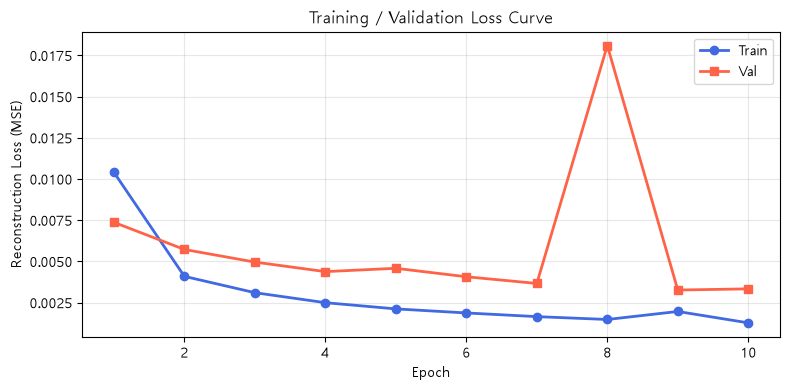

In [33]:
criterion    = nn.MSELoss()
optimizer    = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler    = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

train_losses = []
val_losses   = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    epoch_loss = 0.0
    for images, _ in tqdm(train_loader, desc=f'Epoch {epoch:02d}/{EPOCHS} [train]', leave=False):
        images = images.to(device)
        recon  = model(images)
        loss   = criterion(recon, images)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * images.size(0)

    scheduler.step()
    avg_train_loss = epoch_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # ── Val ──
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, _ in val_loader:
            images = images.to(device)
            recon  = model(images)
            loss   = criterion(recon, images)
            val_loss += loss.item() * images.size(0)
    avg_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(avg_val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch [{epoch:02d}/{EPOCHS}]  Train Loss: {avg_train_loss:.6f}  |  Val Loss: {avg_val_loss:.6f}')

# 학습 곡선
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', linewidth=2, color='royalblue', label='Train')
plt.plot(range(1, EPOCHS+1), val_losses,   marker='s', linewidth=2, color='tomato',    label='Val')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('Training / Validation Loss Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'train_val_loss.png'), dpi=150)
plt.show()

## 7. Test 데이터 복원 오차 계산 (Anomaly Score)

In [34]:
def compute_reconstruction_errors(model, dataloader):
    model.eval()
    errors, labels_list = [], []
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Computing errors'):
            images = images.to(device)
            recon  = model(images)
            mse    = ((recon - images) ** 2).mean(dim=[1, 2, 3])
            errors.extend(mse.cpu().numpy())
            labels_list.extend(labels.numpy())
    return np.array(errors), np.array(labels_list)


# Test 셋 (MOL + INC, 라벨 0+1) 으로 평가
test_errors, test_labels = compute_reconstruction_errors(model, test_loader)
binary_labels = test_labels.astype(int)  # 0=정상, 1=불량

print(f'테스트셋  라벨 0 (정상) : {(binary_labels == 0).sum()}개')
print(f'테스트셋  라벨 1 (불량) : {(binary_labels == 1).sum()}개')
print(f'라벨 0 평균 복원 오차   : {test_errors[binary_labels==0].mean():.6f}')
print(f'라벨 1 평균 복원 오차   : {test_errors[binary_labels==1].mean():.6f}')

Computing errors: 100%|██████████| 74/74 [00:27<00:00,  2.66it/s]

테스트셋  라벨 0 (정상) : 1351개
테스트셋  라벨 1 (불량) : 995개
라벨 0 평균 복원 오차   : 0.003028
라벨 1 평균 복원 오차   : 0.003193


## 8. 임계값(Threshold) 설정 및 이상 탐지 성능

In [35]:
# 임계값은 val(정상+불량 혼합)이 아니라, train 분포 기준으로 설정하는 것이 이상적이나
# 여기서는 test 내 라벨 0(정상) 분포의 percentile 로 설정
normal_errors = test_errors[binary_labels == 0]
threshold     = np.percentile(normal_errors, THRESHOLD_PERCENTILE)
print(f'임계값 (정상 오차 상위 {100 - THRESHOLD_PERCENTILE}%): {threshold:.6f}')

predictions = (test_errors > threshold).astype(int)
TP = ((predictions == 1) & (binary_labels == 1)).sum()
TN = ((predictions == 0) & (binary_labels == 0)).sum()
FP = ((predictions == 1) & (binary_labels == 0)).sum()
FN = ((predictions == 0) & (binary_labels == 1)).sum()

precision = TP / (TP + FP + 1e-8)
recall    = TP / (TP + FN + 1e-8)
f1        = 2 * precision * recall / (precision + recall + 1e-8)
accuracy  = (TP + TN) / len(binary_labels)
auc_score = roc_auc_score(binary_labels, test_errors)

print(f'\n📊 Test 셋 탐지 성능 (MOL + INC 통합)')
print(f'  Accuracy  : {accuracy:.4f}')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc_score:.4f}')

임계값 (정상 오차 상위 5%): 0.005176

📊 Test 셋 탐지 성능 (MOL + INC 통합)
  Accuracy  : 0.5477
  Precision : 0.0286
  Recall    : 0.0020
  F1-Score  : 0.0038
  ROC-AUC   : 0.6112


## 9. 복원 오차 분포 시각화

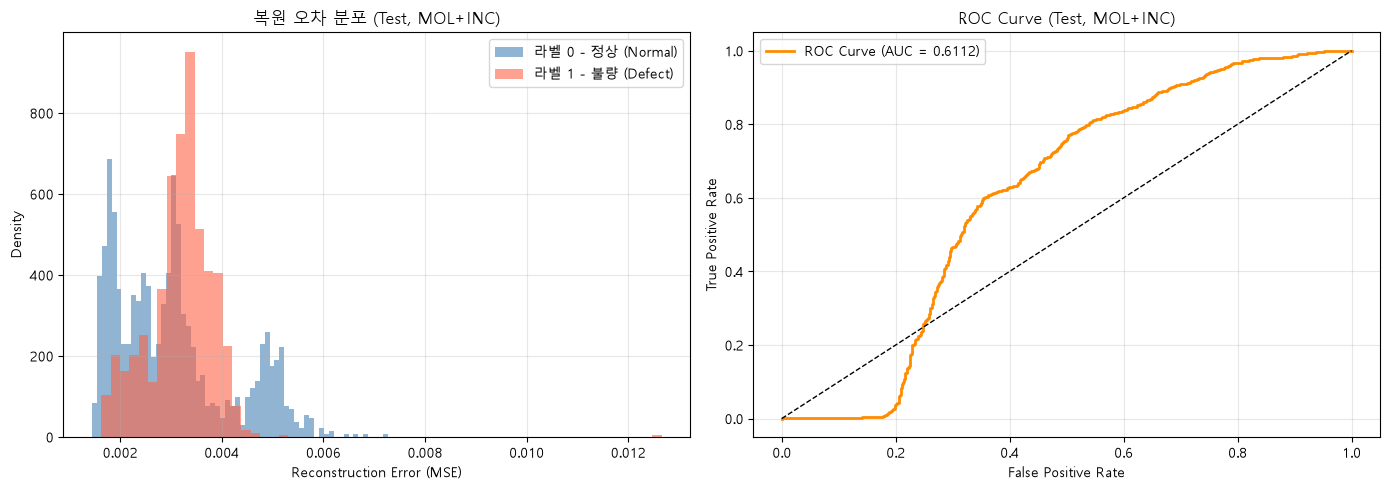

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(test_errors[binary_labels == 0], bins=60, alpha=0.6, color='steelblue', label='라벨 0 - 정상 (Normal)', density=True)
ax.hist(test_errors[binary_labels == 1], bins=60, alpha=0.6, color='tomato',    label='라벨 1 - 불량 (Defect)', density=True)
# ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold:.4f}')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('복원 오차 분포 (Test, MOL+INC)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
fpr, tpr, _ = roc_curve(binary_labels, test_errors)
ax.plot(fpr, tpr, color='darkorange', linewidth=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve (Test, MOL+INC)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'anomaly_detection_results.png'), dpi=150, bbox_inches='tight')
plt.show()

## 10. 복원 이미지 비교 시각화 (정상 vs 불량)

C:\Users\hgh12\AppData\Local\Temp\ipykernel_62316\3321445201.py:32: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
d:\code\Artificial intelligence\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


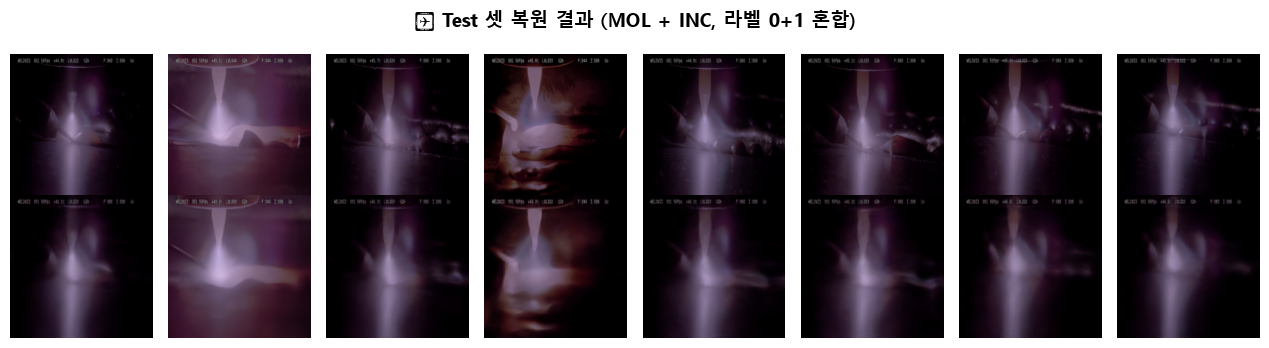

In [37]:
def to_display(t):
    """정규화된 텐서 [-1,1] → 화면 표시용 [0,1] RGB 배열"""
    arr = t.permute(1, 2, 0).numpy()
    return np.clip((arr + 1) / 2, 0, 1)


def show_reconstructions(model, dataset, title, n=8):
    model.eval()
    n       = min(n, len(dataset))
    indices = np.random.choice(len(dataset), n, replace=False)
    images  = torch.stack([dataset[i][0] for i in indices]).to(device)

    with torch.no_grad():
        recons = model(images).cpu()
    images = images.cpu()

    fig, axes = plt.subplots(2, n, figsize=(n * 1.6, 3.5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i in range(n):
        axes[0, i].imshow(to_display(images[i]))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('원본', fontsize=10)

        axes[1, i].imshow(to_display(recons[i]))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('복원', fontsize=10)

        err = ((recons[i] - images[i]) ** 2).mean().item()
        # axes[1, i].set_title(f'{err:.4f}', fontsize=8, color='red')

    plt.tight_layout()
    plt.show()


show_reconstructions(model, test_dataset, '✅ Test 셋 복원 결과 (MOL + INC, 라벨 0+1 혼합)')

## 11. 모델 저장 / 불러오기

In [38]:
torch.save({
    'model_state_dict': model.state_dict(),
    'config'           : {
        'img_mode'    : IMG_MODE,
        'img_channels': IMG_CHANNELS,
        'image_size'  : IMAGE_SIZE,
        'latent_dim'  : LATENT_DIM,
        'sources'     : list(SOURCE_DIRS.keys()),
    }
}, MODEL_SAVE_PATH)
print(f'모델 저장 완료: {MODEL_SAVE_PATH}')

# 불러오기 예시
# checkpoint = torch.load(MODEL_SAVE_PATH, map_location=device)
# model.load_state_dict(checkpoint['model_state_dict'])
# threshold  = checkpoint['threshold']

모델 저장 완료: D:\code\Artificial intelligence\results_split_rgb\autoencoder_split_rgb.pth


# 12. 단일 이미지 이상 판별 (추론 함수) - 이 부분부터 실행하면 됩니다.

In [39]:
# ============================================================
# ✅ 저장된 모델 불러오기 (체크포인트로부터 모델 + 임계값 복원)
# ============================================================
MODEL_LOAD_PATH = r'D:\code\Artificial intelligence\results_split_rgb\autoencoder_split_rgb.pth'

checkpoint = torch.load(MODEL_LOAD_PATH, map_location=device)
config     = checkpoint['config']

print('불러온 모델 설정:')
for k, v in config.items():
    print(f'  {k}: {v}')

# ── 설정값 복원 (이미지 변환에 필요) ──
IMAGE_SIZE   = config['image_size']
LATENT_DIM   = config['latent_dim']
IMG_MODE     = config['img_mode']
IMG_CHANNELS = config['img_channels']

# ── 모델 구조 재생성 (Encoder/Decoder/Autoencoder 클래스가 이미 정의되어 있어야 함) ──
model = Autoencoder(in_channels=IMG_CHANNELS, latent_dim=LATENT_DIM).to(device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()


print(f'\n✅ 모델 불러오기 완료')

# ── 이미지 전처리 transform 재생성 ──
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5] * IMG_CHANNELS,
        std =[0.5] * IMG_CHANNELS
    )
])

print(f'IMAGE_SIZE: {IMAGE_SIZE}, IMG_CHANNELS: {IMG_CHANNELS}, IMG_MODE: {IMG_MODE}')

불러온 모델 설정:
  img_mode: RGB
  img_channels: 3
  image_size: 256
  latent_dim: 512
  sources: ['MOL', 'INC']

✅ 모델 불러오기 완료
IMAGE_SIZE: 256, IMG_CHANNELS: 3, IMG_MODE: RGB


In [40]:
# ============================================================
# ✅ 임의 이미지 폴더 비교 — base(학습 이미지) vs target(확인하고 싶은 이미지)
# ============================================================
BASE_DIR   = r'D:\code\Artificial intelligence\autoencoder img test\base'
TARGET_DIR = r'D:\code\Artificial intelligence\autoencoder img test\target'

IMG_EXTENSIONS_CHECK = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')


def load_and_transform_image(img_path, transform):
    """이미지 1장을 불러와서 모델 입력 형태(텐서)로 변환"""
    img = Image.open(img_path).convert(IMG_MODE)
    return transform(img)


def evaluate_folder(folder_path, model, transform, device):
    """
    폴더 안의 모든 이미지에 대해 Autoencoder를 돌려서
    복원 오차, 원본 텐서, 복원 텐서, 파일명을 리스트로 반환.
    """
    model.eval()
    files = sorted([
        f for f in os.listdir(folder_path)
        if f.lower().endswith(IMG_EXTENSIONS_CHECK)
    ])

    results = []
    with torch.no_grad():
        for fname in files:
            img_path = os.path.join(folder_path, fname)
            img_tensor = load_and_transform_image(img_path, transform).unsqueeze(0).to(device)

            recon = model(img_tensor)
            error = ((recon - img_tensor) ** 2).mean().item()

            results.append({
                'filename': fname,
                'error'   : error,
                'original': img_tensor.cpu().squeeze(0),
                'recon'   : recon.cpu().squeeze(0),
            })

    return results


# ── base / target 폴더 평가 실행 ──
print('base 폴더 평가 중...')
base_results = evaluate_folder(BASE_DIR, model, transform, device)
print(f'  → {len(base_results)}장 처리 완료')

print('target 폴더 평가 중...')
target_results = evaluate_folder(TARGET_DIR, model, transform, device)
print(f'  → {len(target_results)}장 처리 완료')

base_errors   = [r['error'] for r in base_results]
target_errors = [r['error'] for r in target_results]

print(f'\nbase   평균 복원 오차: {np.mean(base_errors):.6f}  (std: {np.std(base_errors):.6f})')
print(f'target 평균 복원 오차: {np.mean(target_errors):.6f}  (std: {np.std(target_errors):.6f})')

base 폴더 평가 중...
  → 1장 처리 완료
target 폴더 평가 중...
  → 1장 처리 완료

base   평균 복원 오차: 0.001676  (std: 0.000000)
target 평균 복원 오차: 0.005579  (std: 0.000000)


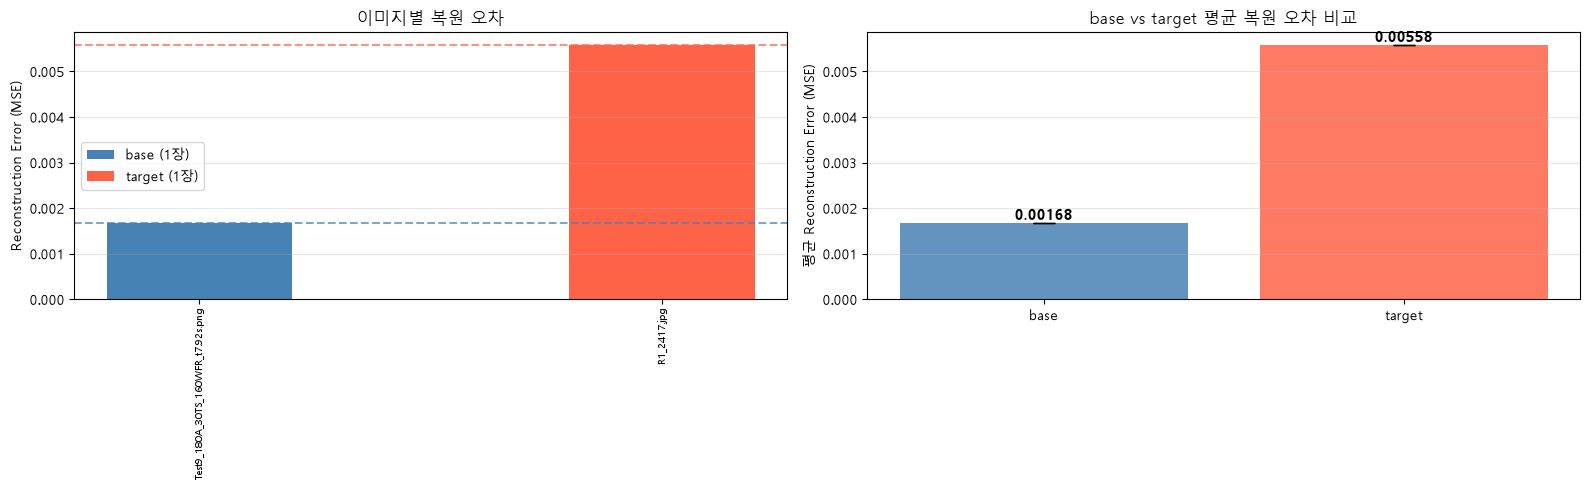


target / base 오차 배율: 3.33배


In [41]:
# ============================================================
# ✅ 막대 그래프 — base vs target 복원 오차 비교
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── 왼쪽: 이미지별 개별 막대 그래프 ──
ax = axes[0]
base_labels   = [r['filename'] for r in base_results]
target_labels = [r['filename'] for r in target_results]

x_base   = np.arange(len(base_errors))
x_target = np.arange(len(target_errors)) + len(base_errors) + 1  # 간격 두고 이어붙임

ax.bar(x_base,   base_errors,   color='steelblue', label=f'base ({len(base_errors)}장)')
ax.bar(x_target, target_errors, color='tomato',     label=f'target ({len(target_errors)}장)')
ax.axhline(np.mean(base_errors), color='steelblue', linestyle='--', linewidth=1.5, alpha=0.7)
ax.axhline(np.mean(target_errors), color='tomato', linestyle='--', linewidth=1.5, alpha=0.7)

ax.set_xticks(list(x_base) + list(x_target))
ax.set_xticklabels(base_labels + target_labels, rotation=90, fontsize=7)
ax.set_ylabel('Reconstruction Error (MSE)')
ax.set_title('이미지별 복원 오차')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# ── 오른쪽: 평균 비교 막대 그래프 ──
ax = axes[1]
groups   = ['base', 'target']
means    = [np.mean(base_errors), np.mean(target_errors)]
stds     = [np.std(base_errors),  np.std(target_errors)]
colors   = ['steelblue', 'tomato']

bars = ax.bar(groups, means, yerr=stds, capsize=8, color=colors, alpha=0.85)
for bar, mean_val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{mean_val:.5f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('평균 Reconstruction Error (MSE)')
ax.set_title('base vs target 평균 복원 오차 비교')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'base_vs_target_error.png'), dpi=150, bbox_inches='tight')
plt.show()

# 배율 출력
ratio = np.mean(target_errors) / (np.mean(base_errors) + 1e-8)
print(f'\ntarget / base 오차 배율: {ratio:.2f}배')

C:\Users\hgh12\AppData\Local\Temp\ipykernel_62316\2403615050.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
d:\code\Artificial intelligence\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


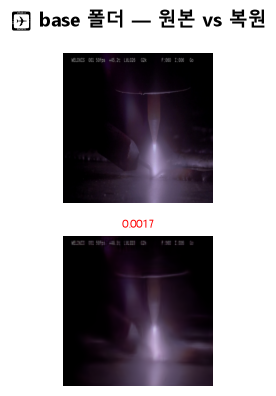

C:\Users\hgh12\AppData\Local\Temp\ipykernel_62316\2403615050.py:29: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
d:\code\Artificial intelligence\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


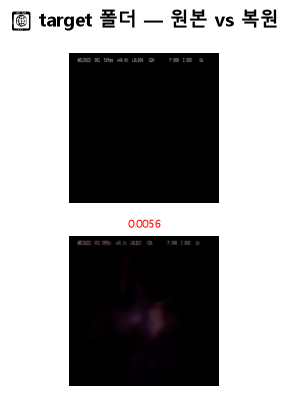

In [42]:
# ============================================================
# ✅ 재구성 이미지 시각화 — base vs target 원본/복원 비교
# ============================================================
def show_folder_reconstructions(results, title, max_n=8):
    """폴더 평가 결과(results)에서 원본/복원 이미지를 나란히 시각화"""
    n = min(max_n, len(results))
    if n == 0:
        print(f'⚠️  {title}: 표시할 이미지가 없습니다.')
        return

    # 오차가 큰 순서로 정렬해서 보여줌 (이상 패턴이 더 눈에 띄도록)
    sorted_results = sorted(results, key=lambda r: r['error'], reverse=True)[:n]

    fig, axes = plt.subplots(2, n, figsize=(n * 1.8, 4))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, r in enumerate(sorted_results):
        axes[0, i].imshow(to_display(r['original']))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('원본', fontsize=10)

        axes[1, i].imshow(to_display(r['recon']))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('복원', fontsize=10)
        axes[1, i].set_title(f'{r["error"]:.4f}', fontsize=8, color='red')

    plt.tight_layout()
    plt.show()


show_folder_reconstructions(base_results,   '✅ base 폴더 — 원본 vs 복원', max_n=8)
show_folder_reconstructions(target_results, '🔍 target 폴더 — 원본 vs 복원', max_n=8)

## 수정해야 할 부분

In [43]:
# ============================================================
# ✅ 1단계 — base 100장 샘플링 (INC/MOL × 0/1, 각 25장씩)
# ============================================================
import random
import shutil

SPLIT_TEST_DIRS = {
    'INC_0': r'D:\code\Artificial intelligence\Split\INC\split\split\test\0',
    'INC_1': r'D:\code\Artificial intelligence\Split\INC\split\split\test\1',
    'MOL_0': r'D:\code\Artificial intelligence\Split\MOL\split\split\test\0',
    'MOL_1': r'D:\code\Artificial intelligence\Split\MOL\split\split\test\1',
}

SAMPLES_PER_GROUP = 25   # 그룹당 25장 × 4그룹 = 100장

AUG_BASE_DIR = r'D:\code\Artificial intelligence\Split\test_augmented'
AUG_METHODS  = ['arc_glare', 'spatter', 'fume_smoke', 'vibration', 'random_two', 'full_mixed']

# base/대응 증강 이미지를 모아둘 비교용 작업 폴더
COMPARE_DIR = r'D:\code\Artificial intelligence\Split\test_compare_100'
COMPARE_BASE_DIR = os.path.join(COMPARE_DIR, 'base')

IMG_EXTENSIONS_CHECK = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.tif')

random.seed(42)  # 재현 가능하도록 시드 고정

os.makedirs(COMPARE_BASE_DIR, exist_ok=True)
for method in AUG_METHODS:
    os.makedirs(os.path.join(COMPARE_DIR, method), exist_ok=True)


def list_images(folder):
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTENSIONS_CHECK)])


# ── 그룹별로 25장씩 랜덤 샘플링 ──
selected_files = {}  # group -> [filename, ...]

for group, folder in SPLIT_TEST_DIRS.items():
    all_files = list_images(folder)
    n_pick = min(SAMPLES_PER_GROUP, len(all_files))
    picked = random.sample(all_files, n_pick)
    selected_files[group] = picked
    print(f'[{group}] 전체 {len(all_files)}장 중 {n_pick}장 샘플링')

total_base = sum(len(v) for v in selected_files.values())
print(f'\n총 base 샘플 수: {total_base}장 (목표 100장)')

[INC_0] 전체 751장 중 25장 샘플링
[INC_1] 전체 909장 중 25장 샘플링
[MOL_0] 전체 600장 중 25장 샘플링
[MOL_1] 전체 86장 중 25장 샘플링

총 base 샘플 수: 100장 (목표 100장)


In [48]:
# ============================================================
# ✅ 2단계 — base 이미지를 작업 폴더로 복사 + 6가지 증강 대응 파일 찾기
#    (정확히 같은 시점(stem)의 증강본만 매칭, 없으면 제외)
# ============================================================

# 증강 폴더 매핑: AUG_BASE_DIR/{method}/{group}/ 안에 원본과 동일한 stem + 태그 형태로 존재
# 예) base: Test9_180A_30TS_160WFR_t5.32s.png
#     증강: Test9_180A_30TS_160WFR_t5.32s_arc_glare.png  ← 동일 시점만 인정
#
# ⚠️ 몰리브덴 파일명에는 마침표(.)가 섞여 있을 수 있어서(예: '35._STO8_...'),
#    os.path.splitext()는 마지막 점만 확장자로 처리하므로 stem 추출 자체는 안전함.
#    문제는 'startswith(stem)' 매칭이 t3.2 / t3.22 처럼 접두사 겹침에 취약하다는 점.
#    → stem 뒤에 반드시 '_' 또는 '.' 가 오는지 확인해서 정확히 일치하는 경우만 채택.

def find_augmented_file(method_dir, group, base_filename):
    """
    base_filename(예: 'Test9_180A_30TS_160WFR_t5.32s.png')과
    정확히 동일한 stem(타임스탬프까지 일치)을 갖는 증강 파일을
    method_dir/group 폴더에서 찾아 반환. 없으면 None.

    매칭 규칙: '{stem}_노이즈태그.png' 형태로, stem 바로 뒤가 '_'로 시작해야 함
               (stem 자체가 다른 stem의 접두사인 경우의 오매칭 방지)
    """
    target_dir = os.path.join(method_dir, group)
    if not os.path.isdir(target_dir):
        return None

    stem = os.path.splitext(base_filename)[0]
    candidates = [
        f for f in os.listdir(target_dir)
        if f.lower().endswith(IMG_EXTENSIONS_CHECK)
        and os.path.splitext(f)[0].startswith(stem + '_')   # stem 뒤에 반드시 '_' 가 와야 함
    ]

    if len(candidates) == 0:
        return None
    if len(candidates) > 1:
        # 동일 stem에 여러 후보가 매칭되면(이론상 드묾) 가장 짧은 것을 우선
        candidates = sorted(candidates, key=len)

    return candidates[0]


# ── base 복사 + 증강 매칭 결과 기록 ──
matched_records = []  # {'group':..., 'base_filename':..., 'method':..., 'aug_filename':...}
missing_records  = []

for group, files in selected_files.items():
    src_folder = SPLIT_TEST_DIRS[group]

    for fname in files:
        # base 이미지 복사
        src_path = os.path.join(src_folder, fname)
        dst_name = f'{group}_{fname}'
        dst_path = os.path.join(COMPARE_BASE_DIR, dst_name)
        shutil.copy2(src_path, dst_path)

        # 6가지 증강 방법에서 동일 시점(stem) 파일 찾아서 복사
        for method in AUG_METHODS:
            method_dir = os.path.join(AUG_BASE_DIR, method)
            aug_fname  = find_augmented_file(method_dir, group, fname)

            if aug_fname is None:
                missing_records.append({'group': group, 'base_filename': fname, 'method': method})
                continue

            aug_src = os.path.join(method_dir, group, aug_fname)
            aug_dst = os.path.join(COMPARE_DIR, method, dst_name)  # base와 동일한 dst_name으로 1:1 매칭 유지
            shutil.copy2(aug_src, aug_dst)

            matched_records.append({
                'group': group, 'base_filename': fname,
                'method': method, 'aug_filename': aug_fname
            })

print(f'✅ base 복사 완료: {sum(len(v) for v in selected_files.values())}장')
print(f'✅ 증강 매칭 성공: {len(matched_records)}건')
if missing_records:
    print(f'⚠️  증강 매칭 실패(동일 시점 증강본 없음): {len(missing_records)}건')
    for m in missing_records[:10]:
        print(f'    - [{m["method"]}] {m["group"]}/{m["base_filename"]}')
    if len(missing_records) > 10:
        print(f'    ... 외 {len(missing_records)-10}건')

✅ base 복사 완료: 100장
✅ 증강 매칭 성공: 0건
⚠️  증강 매칭 실패(동일 시점 증강본 없음): 600건
    - [arc_glare] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [spatter] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [fume_smoke] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [vibration] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [random_two] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [full_mixed] INC_0/Test9_180A_30TS_160WFR_t23.02s.png
    - [arc_glare] INC_0/Test11_180A_40TS_160WFR_t3.22s.png
    - [spatter] INC_0/Test11_180A_40TS_160WFR_t3.22s.png
    - [fume_smoke] INC_0/Test11_180A_40TS_160WFR_t3.22s.png
    - [vibration] INC_0/Test11_180A_40TS_160WFR_t3.22s.png
    ... 외 590건


In [47]:
# ============================================================
# ✅ 3단계 — base + 6가지 증강 각각에 대해 복원 오차 계산
# ============================================================

print('base 평가 중...')
base_results = evaluate_folder(COMPARE_BASE_DIR, model, transform, device)
print(f'  → {len(base_results)}장 처리 완료')

method_results = {}
for method in AUG_METHODS:
    method_dir = os.path.join(COMPARE_DIR, method)
    print(f'{method} 평가 중...')
    method_results[method] = evaluate_folder(method_dir, model, transform, device)
    print(f'  → {len(method_results[method])}장 처리 완료')

base_errors = [r['error'] for r in base_results]
print(f'\nbase 평균 복원 오차: {np.mean(base_errors):.6f} (std: {np.std(base_errors):.6f})\n')

method_errors = {}
for method in AUG_METHODS:
    errors = [r['error'] for r in method_results[method]]
    method_errors[method] = errors
    ratio = np.mean(errors) / (np.mean(base_errors) + 1e-8)
    print(f'{method:12s} 평균 복원 오차: {np.mean(errors):.6f} (std: {np.std(errors):.6f})  |  base 대비 {ratio:.2f}배')

base 평가 중...
  → 100장 처리 완료
arc_glare 평가 중...
  → 0장 처리 완료
spatter 평가 중...
  → 0장 처리 완료
fume_smoke 평가 중...
  → 0장 처리 완료
vibration 평가 중...
  → 0장 처리 완료
random_two 평가 중...
  → 0장 처리 완료
full_mixed 평가 중...
  → 0장 처리 완료

base 평균 복원 오차: 0.003111 (std: 0.000961)

arc_glare    평균 복원 오차: nan (std: nan)  |  base 대비 nan배
spatter      평균 복원 오차: nan (std: nan)  |  base 대비 nan배
fume_smoke   평균 복원 오차: nan (std: nan)  |  base 대비 nan배
vibration    평균 복원 오차: nan (std: nan)  |  base 대비 nan배
random_two   평균 복원 오차: nan (std: nan)  |  base 대비 nan배
full_mixed   평균 복원 오차: nan (std: nan)  |  base 대비 nan배


In [ ]:
# ============================================================
# ✅ 4단계 — base vs 6가지 증강 막대 그래프 비교
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))

groups = ['base'] + AUG_METHODS
means  = [np.mean(base_errors)] + [np.mean(method_errors[m]) for m in AUG_METHODS]
stds   = [np.std(base_errors)]  + [np.std(method_errors[m])  for m in AUG_METHODS]
colors = ['steelblue'] + ['tomato', 'orange', 'mediumpurple', 'seagreen', 'goldenrod', 'crimson']

bars = ax.bar(groups, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
for bar, mean_val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{mean_val:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('평균 Reconstruction Error (MSE)')
ax.set_title(f'base (n={len(base_errors)}) vs 6가지 증강 방법 — 평균 복원 오차 비교')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('base_vs_6augmentations_error.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nbase 대비 오차 배율:')
for m in AUG_METHODS:
    ratio = np.mean(method_errors[m]) / (np.mean(base_errors) + 1e-8)
    print(f'  {m:12s}: {ratio:.2f}배')

In [ ]:
# ============================================================
# ✅ 5단계 — 재구성 이미지 시각화 (base + 6가지 증강 각각)
# ============================================================
def show_folder_reconstructions(results, title, max_n=8):
    """폴더 평가 결과(results)에서 원본/복원 이미지를 나란히 시각화"""
    n = min(max_n, len(results))
    if n == 0:
        print(f'⚠️  {title}: 표시할 이미지가 없습니다.')
        return

    # 오차가 큰 순서로 정렬해서 보여줌 (이상 패턴이 더 눈에 띄도록)
    sorted_results = sorted(results, key=lambda r: r['error'], reverse=True)[:n]

    fig, axes = plt.subplots(2, n, figsize=(n * 1.8, 4))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, r in enumerate(sorted_results):
        axes[0, i].imshow(to_display(r['original']))
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_ylabel('원본', fontsize=10)

        axes[1, i].imshow(to_display(r['recon']))
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_ylabel('복원', fontsize=10)
        axes[1, i].set_title(f'{r["error"]:.4f}', fontsize=8, color='red')

    plt.tight_layout()
    plt.show()


show_folder_reconstructions(base_results, '✅ base — 원본 vs 복원', max_n=8)

for method in AUG_METHODS:
    show_folder_reconstructions(
        method_results[method],
        f'🔍 {method} — 원본 vs 복원',
        max_n=8
    )